# 03 - Target Scoring Baseline
Evaluate removed-part-aware target boundary loop selection.

In [2]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import load_config, ensure_dirs
from src.data.dataset_index import DatasetIndex
from src.data.sample_loader import SampleLoader
from src.geometry.boundary import extract_boundary_loops, loop_perimeter
from src.geometry.bbox import compute_bbox, expand_bbox
from src.target_selection.selectors import select_target_loops_by_bbox, select_largest_loop
from src.target_selection.scorers import loop_proximity_score, loop_overlap_score
from src.target_selection.labeling import label_loops
from tqdm import tqdm

In [3]:
cfg = load_config(os.path.join(PROJECT_ROOT, 'configs', 'chair_leg.yaml'))
ensure_dirs(cfg)
index = DatasetIndex(cfg['paths']['raw_data_dir'])
loader = SampleLoader(cfg['paths']['raw_data_dir'])
margin = cfg['repair']['margin']
prox_thresh = cfg['repair']['proximity_threshold']

In [4]:
# Compare target selection strategies across all samples
selection_stats = []

for sid in tqdm(index.sample_ids, desc="Scoring loops"):
    try:
        sample = loader.load(sid)
        damaged = sample['damaged_mesh']
        removed = sample['removed_part_mesh']
        loops = extract_boundary_loops(damaged)

        if not loops:
            continue

        # Removed-part-aware selection
        rpa_targets = select_target_loops_by_bbox(damaged, loops, removed, margin, prox_thresh)

        # Largest-hole-only selection
        lh_targets = select_largest_loop(damaged, loops)

        # Check if they select the same loops
        rpa_set = set(tuple(l) for l in rpa_targets)
        lh_set = set(tuple(l) for l in lh_targets)
        same_selection = rpa_set == lh_set

        # Score all loops
        scores = []
        for i, loop in enumerate(loops):
            ps = loop_proximity_score(damaged, loop, removed)
            os_ = loop_overlap_score(damaged, loop, removed, margin)
            perim = loop_perimeter(damaged, loop)
            is_rpa_target = any(tuple(loop) == tuple(t) for t in rpa_targets)
            is_lh_target = any(tuple(loop) == tuple(t) for t in lh_targets)
            scores.append({
                'proximity': ps, 'overlap': os_, 'perimeter': perim,
                'is_rpa_target': is_rpa_target, 'is_lh_target': is_lh_target
            })

        selection_stats.append({
            'sample_id': sid,
            'n_loops': len(loops),
            'n_rpa_targets': len(rpa_targets),
            'n_lh_targets': len(lh_targets),
            'same_selection': same_selection,
        })
    except Exception as e:
        print(f"  Error on {sid}: {e}")

df_sel = pd.DataFrame(selection_stats)

Scoring loops: 100%|█████████████████████████████████████████████████████████████████| 100/100 [02:41<00:00,  1.62s/it]


In [5]:
# Summary statistics
n_same = df_sel['same_selection'].sum()
n_diff = len(df_sel) - n_same

print(f"Total samples analyzed: {len(df_sel)}")
print(f"Same selection (RPA == LH): {n_same} ({100*n_same/len(df_sel):.1f}%)")
print(f"Different selection: {n_diff} ({100*n_diff/len(df_sel):.1f}%)")
print(f"\nThis shows that in {100*n_diff/len(df_sel):.1f}% of cases, the largest hole")
print(f"does NOT correspond to the removal-induced opening.")

Total samples analyzed: 84
Same selection (RPA == LH): 0 (0.0%)
Different selection: 84 (100.0%)

This shows that in 100.0% of cases, the largest hole
does NOT correspond to the removal-induced opening.


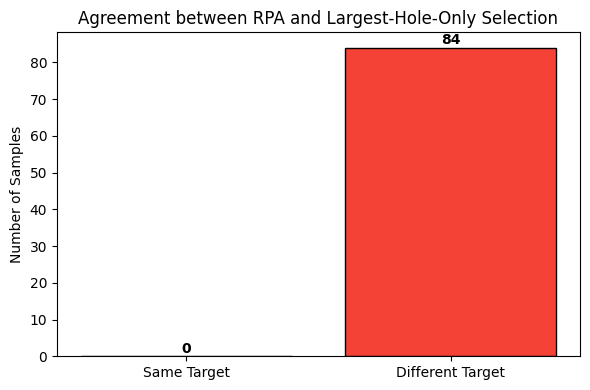

In [6]:
# Plot agreement vs disagreement
fig, ax = plt.subplots(figsize=(6, 4))
categories = ['Same Target', 'Different Target']
counts = [n_same, n_diff]
colors = ['#4CAF50', '#F44336']
ax.bar(categories, counts, color=colors, edgecolor='black')
ax.set_ylabel('Number of Samples')
ax.set_title('Agreement between RPA and Largest-Hole-Only Selection')
for i, (c, v) in enumerate(zip(categories, counts)):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['figures_dir'], 'target_selection_agreement.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()